任务：确定好串扰矩阵的形式（要不要加偏置），还要生成可以用来校准的矩阵（串扰矩阵的逆？）

In [ ]:
!python scripts/gen_data_crosstalk_flux.py --out_npz data/test_flux.npz \
    --n 10 --k 1000 --z_scale 0.3 --quad_strength 0.02 --sat_strength 0.05 --per_strength 0.02 \
    --noise_white 0.01 --noise_pattern 0.005
# !python scripts/gen_data_crosstalk_mw.py --out_npz data/test_mw.npz --n 10 --t 16384 --L 33

Wrote data/test_flux.npz
Shapes: Z (1000, 10), domega_meas (1000, 10), C_true (10, 10), D_true (10, 10, 10)


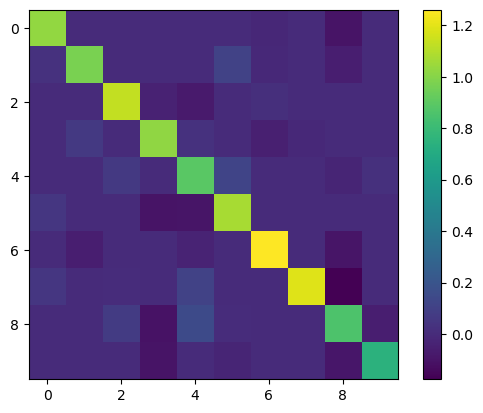

In [30]:
import numpy as np
import matplotlib.pyplot as plt

d = np.load("data/test_flux.npz", allow_pickle=True)

plt.imshow( d["C_true"] )
plt.colorbar()

In [31]:
import numpy as np

data = np.load("data/test_flux.npz")
Z = data["Z"]
domega = data["domega_meas"]
data

NpzFile 'data/test_flux.npz' with keys: Z, domega_meas, C_true, D_true, meta

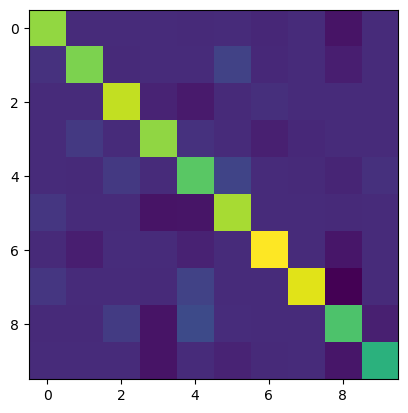

In [24]:
z0 = torch.zeros(10).to(device)
out = eval_response(model, z0)
plt.imshow( out["C"] )

In [15]:
import subprocess
import ast
from pprint import pprint

result = subprocess.run(
    [
        'python', '-m', 'scripts.run_crosstalk_flux', '--in_npz', 'data/test_flux.npz',
        # '--stdout_json', '--out_json', 'sweep.json',
    ],
    stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True
)
# import json
# d = json.loads("sweep.json")



In [21]:
print(result.stderr)


=== Inverse calibration sweep summary (sorted by rmse_test) ===
+--------------+--------------+------------+-----------+-----------------+----------------+----------------+
| model        | fit_time_sec | rmse_train | rmse_test | train_loss_last | test_loss_last | J_offdiag/diag |
+==============+==============+============+===========+=================+================+================+
| mlp          | 3.86581      | 0.0105312  | 0.0162276 | 0.000117453     | 0.000263336    | 0.0277617      |
| residual_mlp | 4.34604      | 0.00764272 | 0.0167259 | 6.36389e-05     | 0.000279755    | 0.0284568      |
| linear       | 3.80589      | 0.0167239  | 0.0168236 | 0.000280548     | 0.000283034    | 0.026649       |
+--------------+--------------+------------+-----------+-----------------+----------------+----------------+



In [2]:
import json
with open("sweep.json", "r", encoding="utf-8") as f:
    d = json.load(f)

d

{'task': 'Inverse calibration model sweep (control = g(target))',
 'in_npz': 'data/test_flux.npz',
 'control_key': 'Z',
 'target_key': 'domega_meas',
 'device': 'cuda',
 'dtype': 'torch.float32',
 'N_samples': 1000,
 'n_channels': 10,
 'train': {'epochs': 1000,
  'lr': 0.002,
  'batch_size': 256,
  'test_frac': 0.1,
  'weight_decay': 0.0,
  'grad_clip': None,
  'seed': 0,
  'split_seed': 0,
  'do_init_from_data': True,
  'init_ridge': 1e-08},
 'models_ran': ['linear', 'mlp', 'residual_mlp'],
 'best_by_rmse_test': 'mlp',
 'comparison_rows_sorted_by_rmse_test': [{'model': 'mlp',
   'fit_time_sec': 3.6065545082092285,
   'rmse_train': 0.010531214065849781,
   'rmse_test': 0.01622762531042099,
   'train_loss_last': 0.00011745300798793323,
   'test_loss_last': 0.00026333582354709506,
   'J_offdiag/diag': 0.027761677280068398,
   'J_diag_mean_abs': 0.8739829063415527,
   'J_offdiag_mean_abs': 0.024263231083750725,
   'init_from_data': {'linear_A': [[0.9035678505897522,
      0.00150819635018

In [14]:
d["per_model"]["linear"]

{'row': {'model': 'linear',
  'fit_time_sec': 4.599480390548706,
  'rmse_train': 0.016723940148949623,
  'rmse_test': 0.016823623329401016,
  'train_loss_last': 0.000280548061709851,
  'test_loss_last': 0.00028303428553044796,
  'J_offdiag/diag': 0.026649001985788345,
  'J_diag_mean_abs': 0.9293407201766968,
  'J_offdiag_mean_abs': 0.024766001850366592,
  'init_from_data': {'linear_A': [[0.9035678505897522,
     0.0015081963501870632,
     -0.007059653755277395,
     0.013362022116780281,
     -0.015690501779317856,
     0.0034824658650904894,
     0.01375996507704258,
     -0.0016675891820341349,
     0.10568300634622574,
     0.007122916169464588],
    [-0.021386515349149704,
     0.9492103457450867,
     -0.0003261936944909394,
     -0.0008602651651017368,
     -0.020112648606300354,
     -0.09334433823823929,
     0.008764212019741535,
     0.00044623014400713146,
     0.05835157632827759,
     0.0034606067929416895],
    [-0.0013821751344949007,
     -0.0013645983999595046,
     0

In [3]:
print(result.stderr)


=== Inverse calibration sweep summary (sorted by rmse_test) ===
+--------------+--------------+------------+-----------+-----------------+----------------+----------------+
| model        | fit_time_sec | rmse_train | rmse_test | train_loss_last | test_loss_last | J_offdiag/diag |
+==============+==============+============+===========+=================+================+================+
| mlp          | 3.60655      | 0.0105312  | 0.0162276 | 0.000117453     | 0.000263336    | 0.0277617      |
| residual_mlp | 4.00016      | 0.00764272 | 0.0167259 | 6.36389e-05     | 0.000279755    | 0.0284568      |
| linear       | 4.59948      | 0.0167239  | 0.0168236 | 0.000280548     | 0.000283034    | 0.026649       |
+--------------+--------------+------------+-----------+-----------------+----------------+----------------+

